# PseudoVelo Case 1 - Comprehensive Evaluation and Robustness Analysis

In [ ]:
import warnings, sys, os
import logging
def customwarn(message, category, filename, lineno, file=None, line=None):
    pass
warnings.showwarning = customwarn
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message="No data for colormapping provided via 'c'.*")
warnings.filterwarnings("ignore", message=".*Negative binomial dispersion parameter alpha not set.*")
warnings.filterwarnings("ignore", module="statsmodels.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger().setLevel(logging.ERROR) 
os.environ['PYTHONWARNINGS'] = 'ignore'

import scanpy as sc
sc.settings.verbosity = 0 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pseudovelo as pv
import cellrank as cr
from cellmapper import CellMapper
from cellrank.kernels import CytoTRACEKernel
from transition import evaluate_transition_accuracy, projection_consistency, cross_projection_consistency

np.random.seed(0)

In [2]:
def plot_projection_consistency_boxplot(data, labels=None):
    plt.figure(figsize=(2.5, 2.5))
    sns.boxplot(data=data, width=0.2, palette="Set2", fliersize=2)
    for i, d in enumerate(data):
        plt.text(i + 0.15, np.nanmedian(d), f'{np.nanmedian(d):.2f}', ha='left', va='center', fontsize=8)
    plt.ylabel('Projection Consistency', fontsize=10)
    if labels is not None:
        plt.xticks(range(len(labels)), labels, fontsize=10)
    else:
        plt.xticks(fontsize=10, rotation=15)
    sns.despine()
    plt.tight_layout()
    plt.show()

def load_and_preprocess_data(subsample_cells=False, subsample_genes=False):
    
    adata = sc.read_h5ad("./data/zebrafish/zebrafish_embryogenesis_axial_mesoderm.h5ad")
    adata.obsm["X_force_directed"] = adata.obsm["X_force_directed"][:, :2]
    adata = adata[~np.any(np.isnan(adata.obsm["X_force_directed"]), axis=1)].copy()
    
    if subsample_cells:
        sc.pp.subsample(adata, fraction=0.5)
    if subsample_genes:
        adata = adata[:, np.random.choice(adata.n_vars, size=adata.n_vars // 2, replace=False)].copy()
        
    sc.pp.filter_genes(adata, min_cells=10)
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)
    adata = adata[:, adata.var.highly_variable].copy()
    sc.tl.pca(adata)
    sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
    return adata

def find_root_index(adata, col_name, val, rightmost=False):
    
    idx = np.where(adata.obs[col_name] == val)[0]
    if rightmost:
        umap_x_coords = adata.obsm["X_force_directed"][idx, 0]
        return idx[np.argmax(umap_x_coords)]
    else:
        return np.random.choice(idx)

def run_eval_pipeline(adata, time_key="dpt_pseudotime", cluster_key="lineages", run_dpt=True, root_idx=None, ctk=None):
    
    # 1. DPT Root
    if run_dpt and root_idx is not None:
        adata.uns["iroot"] = root_idx
        sc.tl.diffmap(adata)
        sc.tl.dpt(adata)
        fig, ax = plt.subplots(figsize=(3,3))
        sc.pl.embedding(adata, color="dpt_pseudotime", show=False, basis="X_force_directed", ax=ax, frameon=False)
        plt.scatter(adata.obsm["X_force_directed"][root_idx, 0], adata.obsm["X_force_directed"][root_idx, 1], 
                    color='red', marker='*', s=200, edgecolors='black', zorder=5)
        plt.show()



    # 2. PseudoVelo
    adata.layers["X"] = adata.X.toarray()
    pv.fit_nb_gam_with_center_diff(adata, J_key=time_key, n_jobs=10, cluster_key=cluster_key, input_layer="X", reverse=False)
    pv.plot_velocity_projection(adata, xkey="X", vkey="gam_nb_dmu_dJ", basis="force_directed", 
                                color="lineages", figsize=(3,3), title="PseudoVelo", size=120, legend_loc="none")

    # 3. CellRank2
    if time_key == "dpt_pseudotime":
        kernel = cr.kernels.PseudotimeKernel(adata, time_key=time_key)
        kernel.compute_transition_matrix()
        kernel.write_to_adata()
        
        kernel.plot_projection(basis="force_directed", color="lineages", show=False, figsize=(3,3), 
                            title="CellRank2", s=120, legend_fontsize=8, legend_loc="none")
        plt.gca().grid(False)
        plt.show()
    else:
        kernel = ctk

    # 4. Quantitative Analysis 1: Consistency
    c_pv = projection_consistency(adata, embedding_key='X_force_directed', l2_norm=False)
    c_cr2 = projection_consistency(adata, embedding_key='X_force_directed', l2_norm=False, T_velo=kernel.transition_matrix)
    adata.obs[f'consistency_{time_key}_pv'] = c_pv
    adata.obs[f'consistency_{time_key}_cr2'] = c_cr2
    plot_projection_consistency_boxplot([c_pv, c_cr2], labels=["PseudoVelo", "CellRank2"])

    # 5. Quantitative Analysis 2: Transition Accuracy
    order = ['03.3-HIGH', '03.8-OBLONG', '04.3-DOME', '04.8-30%', '05.3-50%', '06.0-SHIELD', 
             '07.0-60%', '08.0-75%', '09.0-90%', '10.0-BUD', '11.0-3-Somite', '12.0-6-Somite']
    acc_pv = evaluate_transition_accuracy(adata, cluster_key='Stage', lineage_order=order, vkey='gam_nb_dmu_dJ')
    acc_cr2 = evaluate_transition_accuracy(adata, cluster_key='Stage', lineage_order=order, T=kernel.transition_matrix)
    print(f"{time_key} - pv accuracy:", acc_pv)
    print(f"{time_key} - cr2 accuracy:", acc_cr2)

    # 6. GPCCA Analysis
    g_cr2 = cr.estimators.GPCCA(kernel)
    g_cr2.compute_macrostates(cluster_key="lineages", n_states=3)
    g_cr2.predict_terminal_states()
    g_cr2.predict_initial_states(allow_overlap=True)
    g_cr2.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="force_directed", figsize=(4,4))
    g_cr2.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="force_directed", figsize=(4,4))

    vk = cr.kernels.VelocityKernel(adata, vkey="gam_nb_dmu_dJ", xkey="X")
    vk.compute_transition_matrix()
    g_pv = cr.estimators.GPCCA(vk)
    g_pv.compute_macrostates(n_states=3, cluster_key="lineages")
    g_pv.predict_initial_states()
    g_pv.predict_terminal_states(allow_overlap=True)
    g_pv.plot_macrostates(which="initial", legend_loc="on data", s=100, basis="force_directed", figsize=(4,4))
    g_pv.plot_macrostates(which="terminal", legend_loc="on data", s=100, basis="force_directed", figsize=(4,4))
    
    return adata, kernel

### Part 1: Standard Evaluation and CytoTRACE Comparison

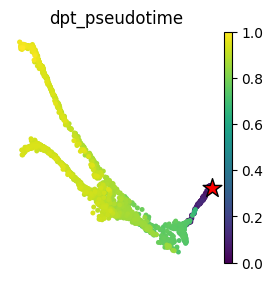

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.855), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.225), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.27), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


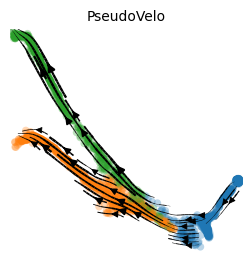

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

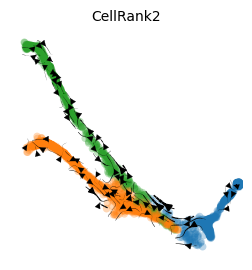

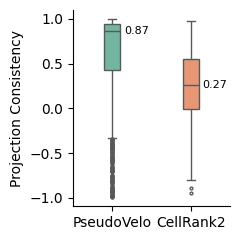

dpt_pseudotime - pv accuracy: 0.80646354
dpt_pseudotime - cr2 accuracy: 0.5439105331684255


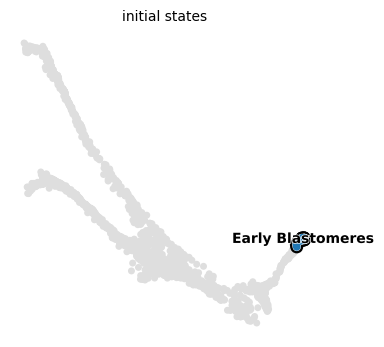

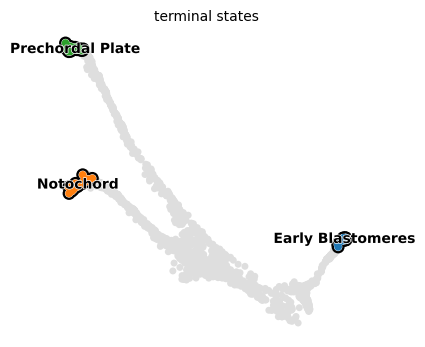

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

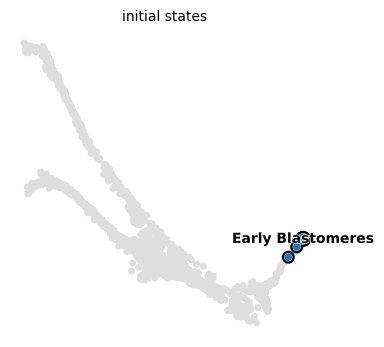

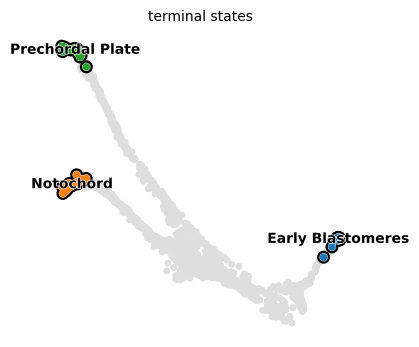

In [3]:
# 1.1 DPT Standard
adata_dpt = load_and_preprocess_data()
root_idx = find_root_index(adata_dpt, "Stage", "03.3-HIGH", rightmost=True)
adata_dpt, pk = run_eval_pipeline(adata_dpt, time_key="dpt_pseudotime", root_idx=root_idx)


INFO     Initialized CellMapper for self-mapping with 2341 cells.                                                  
INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using kernel method 'umap'.                                                      
INFO     Mapping layer for key 'X' using direct multiplication                                                     
INFO     Imputed expression matrix with shape (2341, 13635) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             
INFO     Expression for layer 'X' mapped and stored in query_imputed.X. 

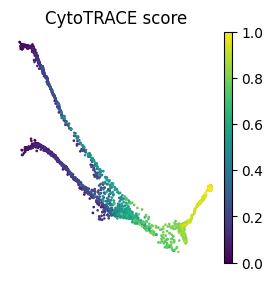

  0%|          | 0/2341 [00:00<?, ?cell/s]

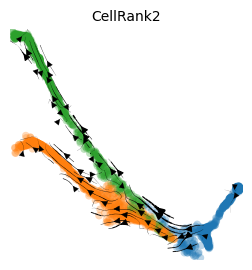

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 5 (factor = 0.415), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.83), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 8 (factor = 0.797), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


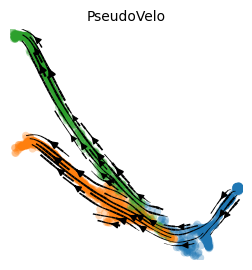

computing velocity embedding
finished.


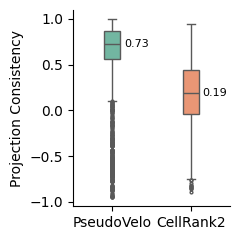

ct_pseudotime - pv accuracy: 0.7381438
ct_pseudotime - cr2 accuracy: 0.5918897617478305


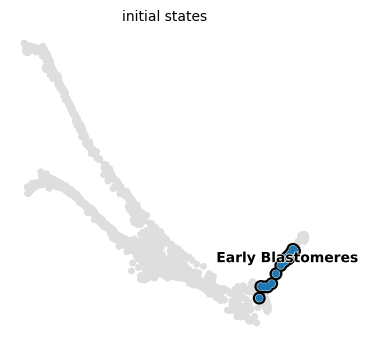

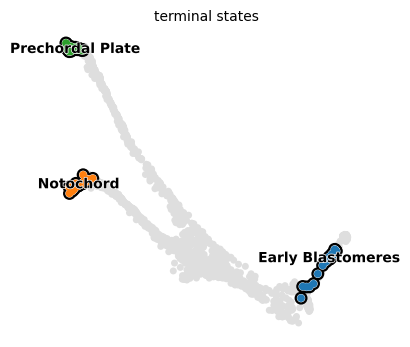

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

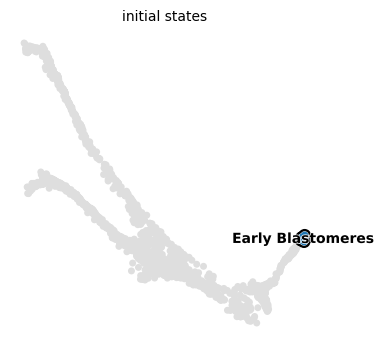

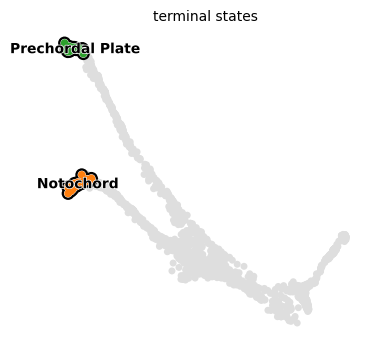

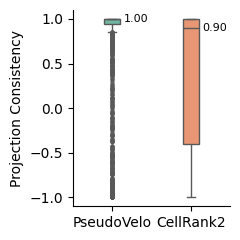

In [ ]:
# 1.2 CytoTRACE Analysis
adata_ct = sc.read_h5ad("./data/zebrafish/zebrafish_embryogenesis_axial_mesoderm.h5ad")
adata_ct.obsm["X_force_directed"] = adata_ct.obsm["X_force_directed"][:, :2]
adata_ct = adata_ct[~np.any(np.isnan(adata_ct.obsm['X_force_directed']), axis=1)].copy()
adata = adata_ct.copy()
sc.pp.filter_genes(adata_ct, min_cells=10)
sc.pp.normalize_total(adata_ct)
sc.pp.log1p(adata_ct)
sc.pp.highly_variable_genes(adata_ct, n_top_genes=2000)
sc.tl.pca(adata_ct)
sc.pp.neighbors(adata_ct, n_neighbors=30, n_pcs=30)

adata_ct.layers["imputed"] = CellMapper(adata_ct).map(layer_key="X", use_rep="X_pca").query_imputed.X.copy()
ctk = CytoTRACEKernel(adata_ct).compute_cytotrace(layer="imputed")
adata_ct.obs["1_minus_pseudotime"] = 1 - adata_ct.obs["ct_pseudotime"]
fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_ct, basis="force_directed", color="1_minus_pseudotime", frameon=False, ax=ax, size=15, title="CytoTRACE score", legend_fontsize=8)
ctk.compute_transition_matrix(threshold_scheme="soft", nu=0.5)
ctk.plot_projection(basis="force_directed",color="lineages",figsize=(3,3),title="CellRank2",size=120,legend_loc="none",show=False)
ax = plt.gca()
ax.grid(False)
plt.show()

# Build adata for PV (align genes)
sc.pp.filter_genes(adata, min_cells=10)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata = adata[:, adata.var.highly_variable].copy()
adata.obs["ct_pseudotime"] = adata_ct.obs["ct_pseudotime"]
adata_ct_pv, ctk = run_eval_pipeline(adata, time_key="ct_pseudotime", cluster_key="lineages", run_dpt=False, ctk=ctk)

# 1.3 Cross Projection Consistency

acc_cross1 = cross_projection_consistency(adata_dpt, adata_ct_pv, vkey="gam_nb_dmu_dJ",embedding_key="X_force_directed")
acc_cross2 = cross_projection_consistency(adata1=adata_dpt,T_velo1=pk.transition_matrix, T_velo2=ctk.transition_matrix,embedding_key="X_force_directed")
data_list3 = [
        acc_cross1, 
        acc_cross2
    ]
plot_projection_consistency_boxplot(data_list3, labels=["PseudoVelo", "CellRank2"])

### Part 2: Robustness Analysis
Test the impact of re-clustering, cell subsampling, and gene subsampling on the results.


--- Running Robustness: Re-clustering (Leiden) ---


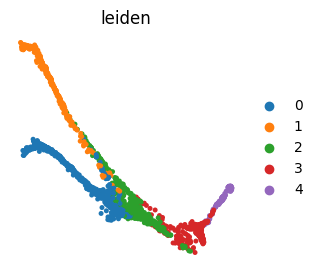

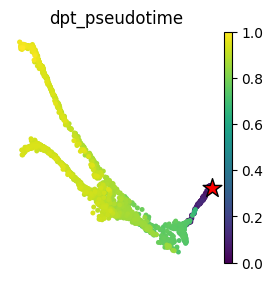

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'leiden', n_clusters = 5
[cluster=0] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0777), n_jobs = 10.
[cluster=1] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.114), n_jobs = 10.
[cluster=2] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.0796), n_jobs = 10.
[cluster=3] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.167), n_jobs = 10.
[cluster=4] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.126), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


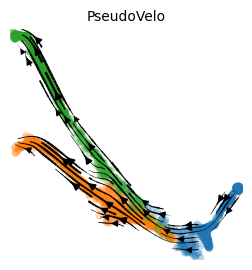

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

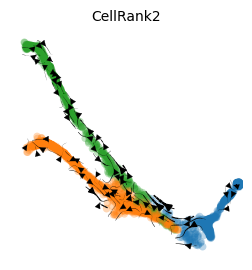

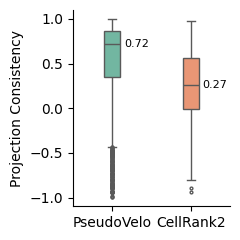

dpt_pseudotime - pv accuracy: 0.77344304
dpt_pseudotime - cr2 accuracy: 0.5439105331684255


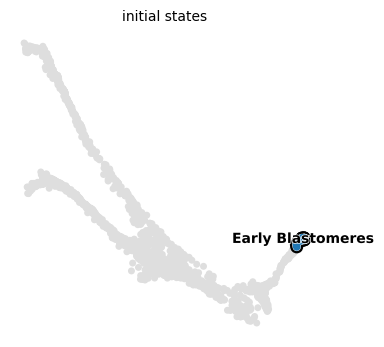

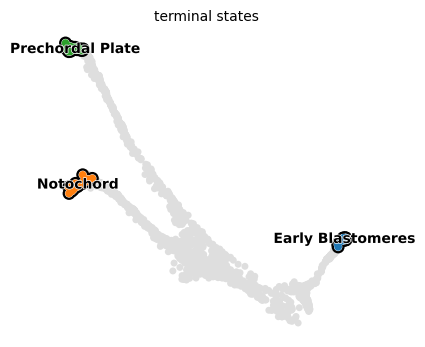

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

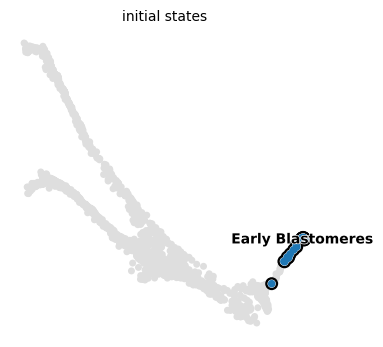

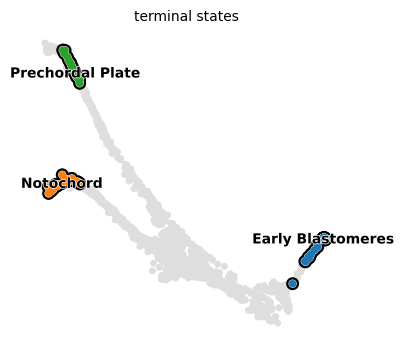


--- Running Robustness: Cell Subsampling ---


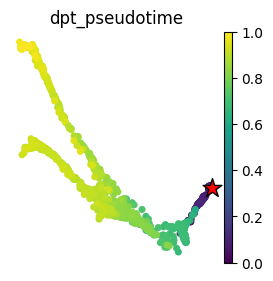

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.817), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.265), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.33), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (1170, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (1170, 2000)


  0%|          | 0/1170 [00:00<?, ?cells/s]

computing velocity graph
finished.


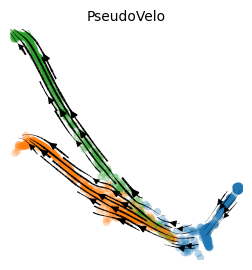

computing velocity embedding
finished.


  0%|          | 0/1170 [00:00<?, ?cell/s]

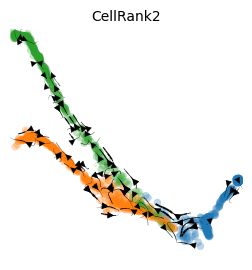

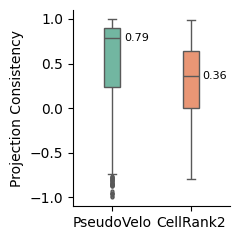

dpt_pseudotime - pv accuracy: 0.79713744
dpt_pseudotime - cr2 accuracy: 0.5429242725342786


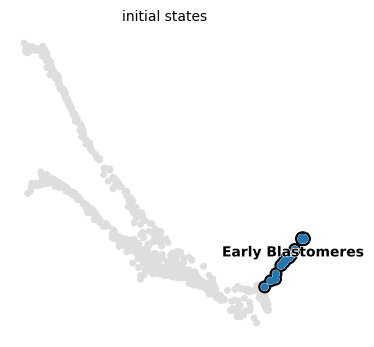

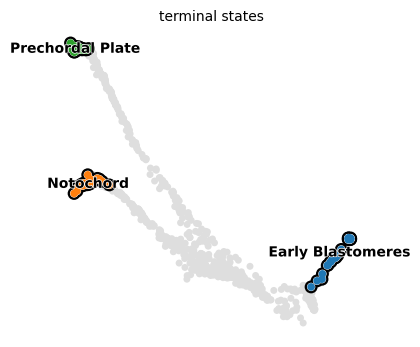

  0%|          | 0/1170 [00:00<?, ?cell/s]

  0%|          | 0/1170 [00:00<?, ?cell/s]

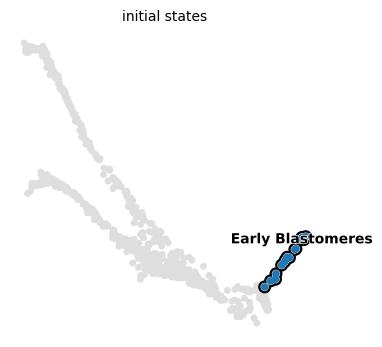

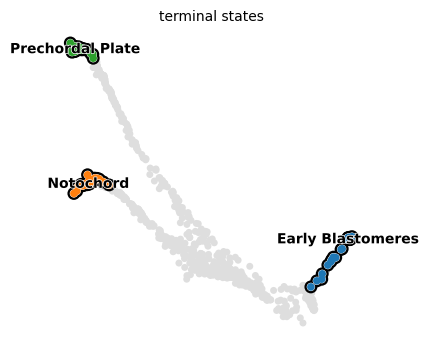


--- Running Robustness: Gene Subsampling ---


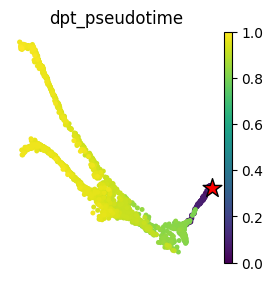

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 10 (factor = 0.91), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.163), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.184), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


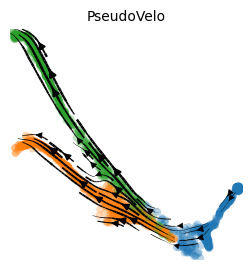

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

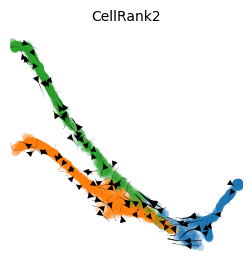

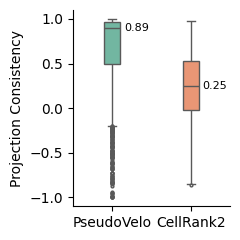

dpt_pseudotime - pv accuracy: 0.7783583
dpt_pseudotime - cr2 accuracy: 0.5259725559563763


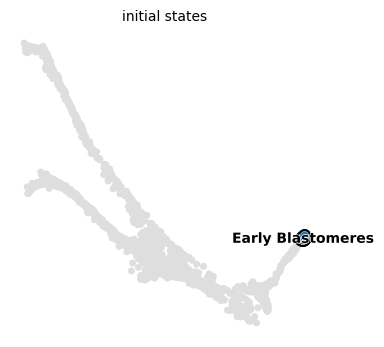

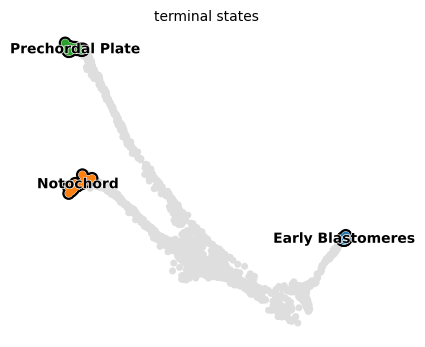

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

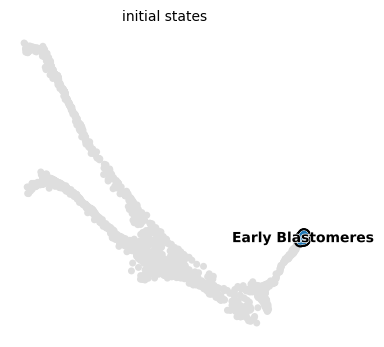

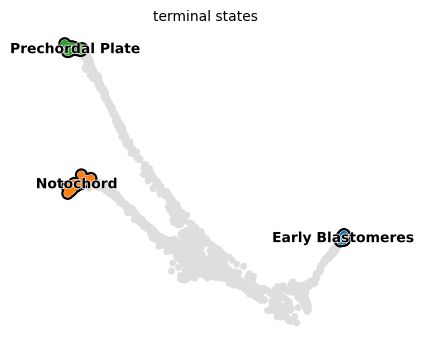

In [5]:
# 2.1 Re-clustering Test
print("\n--- Running Robustness: Re-clustering (Leiden) ---")
adata_rob_cluster = load_and_preprocess_data()
sc.tl.leiden(adata_rob_cluster, resolution=0.2)
fig, ax = plt.subplots(figsize=(3,3))
sc.pl.embedding(adata_rob_cluster, color="leiden", basis="X_force_directed", ax=ax, frameon=False)

root_idx = find_root_index(adata_rob_cluster, "Stage", "03.3-HIGH", rightmost=True)
_ = run_eval_pipeline(adata_rob_cluster, cluster_key="leiden", root_idx=root_idx)

# 2.2 Cell Subsampling Test
print("\n--- Running Robustness: Cell Subsampling ---")
adata_rob_cell = load_and_preprocess_data(subsample_cells=True)
root_idx = find_root_index(adata_rob_cell, "Stage", "03.3-HIGH", rightmost=True)
_ = run_eval_pipeline(adata_rob_cell, root_idx=root_idx)

# 2.3 Gene Subsampling Test
print("\n--- Running Robustness: Gene Subsampling ---")
adata_rob_gene = load_and_preprocess_data(subsample_genes=True)
root_idx = find_root_index(adata_rob_gene, "Stage", "03.3-HIGH", rightmost=True)
_ = run_eval_pipeline(adata_rob_gene, root_idx=root_idx)

### Part 3: Different Root Tests


--- Testing Root: Early Blastomeres ---


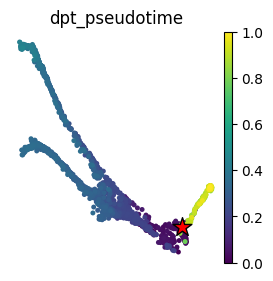

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 10 (factor = 1), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.361), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 5 (factor = 0.441), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


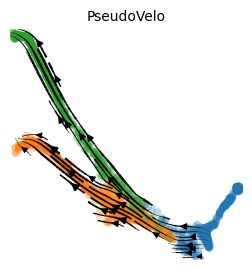

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

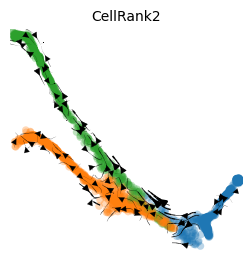

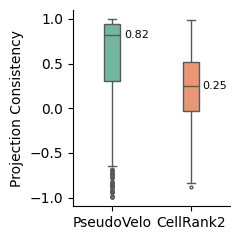

dpt_pseudotime - pv accuracy: 0.7805413
dpt_pseudotime - cr2 accuracy: 0.5489558257478391


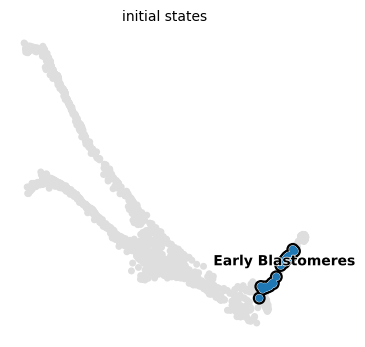

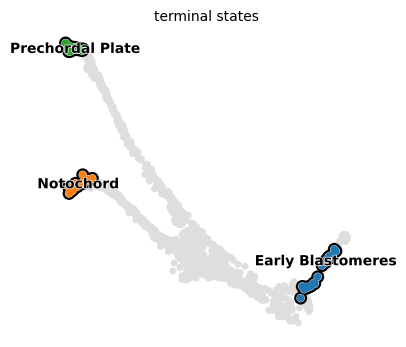

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

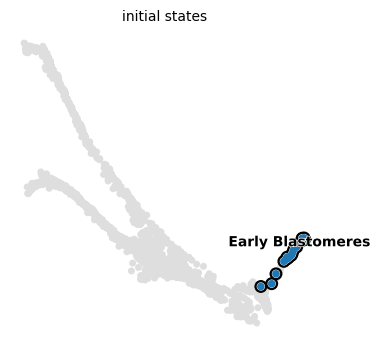

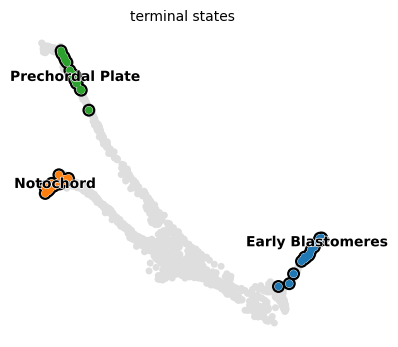


--- Testing Root: Notochord ---


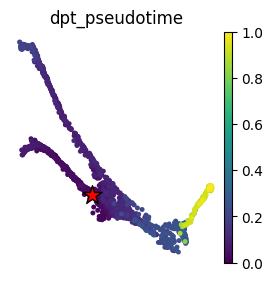

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.885), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.255), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.229), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


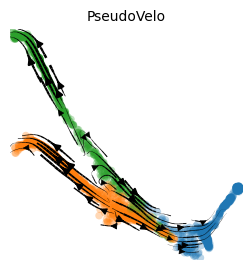

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

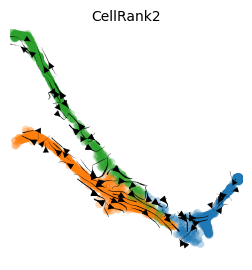

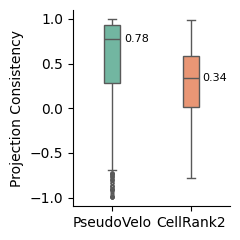

dpt_pseudotime - pv accuracy: 0.6492378
dpt_pseudotime - cr2 accuracy: 0.509112742529327


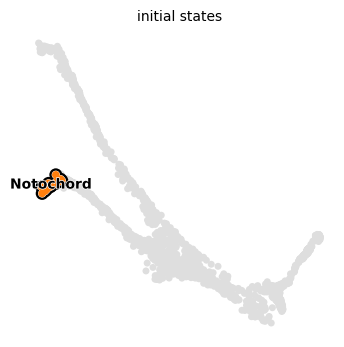

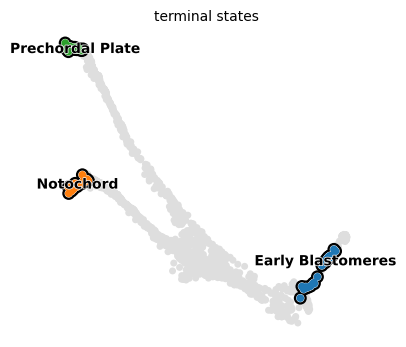

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

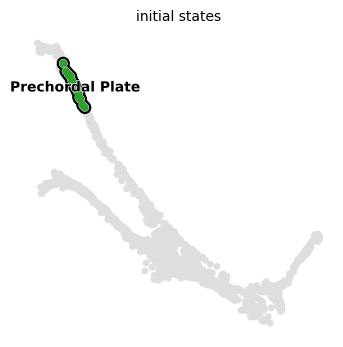

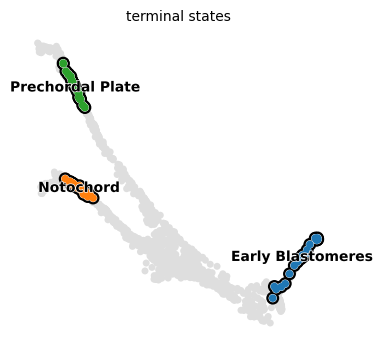


--- Testing Root: Prechordal Plate ---


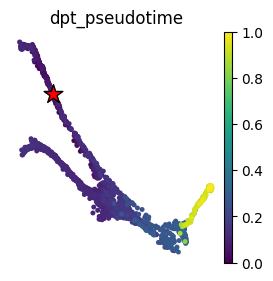

[global] J range = 1, eps = 1e-06 (eps_factor = 1e-06)
Fitting NB GLMGam per cluster, cluster_key = 'lineages', n_clusters = 3
[cluster=Early Blastomeres] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 9 (factor = 0.836), n_jobs = 10.
[cluster=Notochord] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.21), n_jobs = 10.
[cluster=Prechordal Plate] Fitting NB GLMGam for 2000 genes (center difference), k_mu_sub = 4 (factor = 0.29), n_jobs = 10.
Stored μ in adata.layers['gam_nb_mu'] with shape (2341, 2000)
Stored dμ/dJ in adata.layers['gam_nb_dmu_dJ'] with shape (2341, 2000)


  0%|          | 0/2341 [00:00<?, ?cells/s]

computing velocity graph
finished.


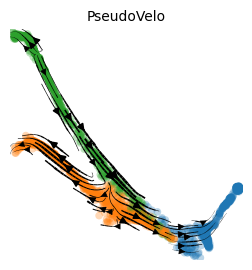

computing velocity embedding
finished.


  0%|          | 0/2341 [00:00<?, ?cell/s]

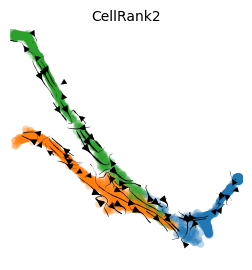

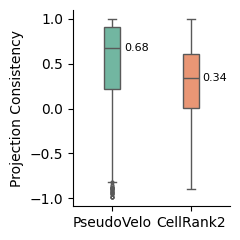

dpt_pseudotime - pv accuracy: 0.5726741
dpt_pseudotime - cr2 accuracy: 0.4964625300108333


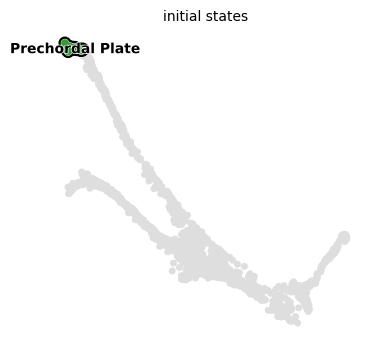

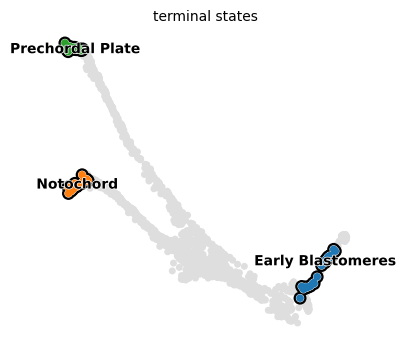

  0%|          | 0/2341 [00:00<?, ?cell/s]

  0%|          | 0/2341 [00:00<?, ?cell/s]

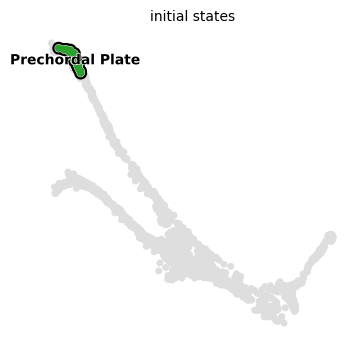

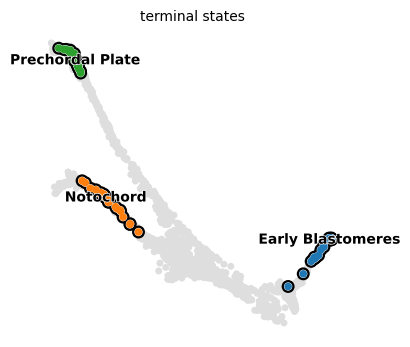

In [6]:
root_clusters = ["Early Blastomeres", "Notochord", "Prechordal Plate"]
np.random.seed(0)
for target_cluster in root_clusters:
    print(f"\n{'='*50}")
    print(f"--- Testing Root: {target_cluster} ---")
    print(f"{'='*50}")
    
    adata_test_root = load_and_preprocess_data()
    root_idx = find_root_index(adata_test_root, "lineages", target_cluster, rightmost=False)
    _ = run_eval_pipeline(adata_test_root, root_idx=root_idx,time_key = "dpt_pseudotime")